In [7]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END, START
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

load_dotenv()

True

In [9]:
class State(TypedDict):
    query: str
    category: str
    confidence: float
    sentiment: str
    response: str
    quality_score: float
    context: str


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

parser = StrOutputParser()

In [10]:
def load_pdfs(pdf_paths: list) -> list:
    """Load all PDF files and return a flat list of documents."""
    all_docs = []
    for path in pdf_paths:
        loader = PyMuPDFLoader(path)
        docs = loader.load()
        all_docs.extend(docs)
        print(f"Loaded {len(docs)} pages from {path}")
    return all_docs


pdf_paths = [
    "./docs/novatech_technical_faq.pdf",
    "./docs/novatech_billing_faq.pdf",
    "./docs/novatech_general_faq.pdf",
]

docs = load_pdfs(pdf_paths)
print(f"\nTotal pages loaded: {len(docs)}")

Loaded 2 pages from ./docs/novatech_technical_faq.pdf
Loaded 2 pages from ./docs/novatech_billing_faq.pdf
Loaded 2 pages from ./docs/novatech_general_faq.pdf

Total pages loaded: 6


In [11]:
# Split into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
)
chunks = splitter.split_documents(docs)
print(f"Total chunks created: {len(chunks)}")

# Build FAISS vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

print("\nKnowledge base built successfully!")

Total chunks created: 31

Knowledge base built successfully!


In [12]:
class QueryCategorySchema(BaseModel):
    category: Literal["Technical", "Billing", "General"] = Field(..., description="The category of the customer query: Technical, Billing, or General.")
    confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence score between 0.0 and 1.0 for the category classification.")

class QualityCheckSchema(BaseModel):
    quality_score: float = Field(..., ge=0.0, le=1.0, description="Quality score between 0.0 and 1.0. Score above 0.7 means the response is helpful and addresses the query.")
    feedback: str = Field(..., description="Brief feedback on why the response is or isn't helpful.")

class SentimentAnalysisSchema(BaseModel):
    sentiment: Literal["Positive", "Neutral", "Negative"] = Field(..., description="The sentiment of the customer query: Positive, Neutral, or Negative.")

def categorize(state: State) -> State:
    """Categorize the customer query into Technical, Billing, or General."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Categorize the following customer query into one of these categories: Technical, Billing, General. Also provide a confidence score between 0.0 and 1.0."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm.with_structured_output(QueryCategorySchema)
    result = chain.invoke({"query": state["query"]})
    return {
        "category": result.category,
        "confidence": result.confidence, 
    }

def analyze_sentiment(state: State) -> State:
    """Analyze the sentiment of the customer query as Positive, Neutral, or Negative."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Analyze the sentiment of the following customer query. Respond with either 'Positive', 'Neutral', or 'Negative'."),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm.with_structured_output(SentimentAnalysisSchema)
    sentiment = chain.invoke({"query": state["query"]})
    return {"sentiment": sentiment.sentiment}

def handle_technical(state: State) -> State:
    """Provide a technical support response grounded in knowledge base context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a technical support agent.
Use the following knowledge base context to answer the query.
If the context is relevant use it. If not, answer from your general knowledge.

Context:
{context}"""),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({
        "query": state["query"],
        "context": state["context"]
    })
    return {"response": response}


def handle_billing(state: State) -> State:
    """Provide a billing support response grounded in knowledge base context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a billing support agent.
Use the following knowledge base context to answer the query.
If the context is relevant use it. If not, answer from your general knowledge.

Context:
{context}"""),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({
        "query": state["query"],
        "context": state["context"]
    })
    return {"response": response}


def handle_general(state: State) -> State:
    """Provide a general support response grounded in knowledge base context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a general support agent.
Use the following knowledge base context to answer the query.
If the context is relevant use it. If not, answer from your general knowledge.

Context:
{context}"""),
        ("user", "Query: {query}")
    ])
    chain = prompt | llm | parser
    response = chain.invoke({
        "query": state["query"],
        "context": state["context"]
    })
    return {"response": response}

def escalate(state: State) -> State:
    """Escalate the query to a human agent due to negative sentiment."""
    return {"response": "This query has been escalated to a human agent due to its negative sentiment."}

def quality_check(state: State) -> State:
    """Check if the generated response is helpful and relevant to the query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a quality assurance reviewer for customer support responses.
Score the response on a scale of 0.0 to 1.0 based on:
- Does it directly address the query?
- Is it helpful and actionable?
- Is it professional and clear?"""),
        ("user", "Query: {query}\n\nResponse: {response}")
    ])
    chain = prompt | llm.with_structured_output(QualityCheckSchema)
    result = chain.invoke({
        "query": state["query"],
        "response": state["response"]
    })
    return {"quality_score": result.quality_score}


def regenerate_response(state: State) -> State:
    """Regenerate a better response if quality check failed."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """The previous response was not helpful enough.
Generate a better, more detailed and actionable response.
Category: {category}"""),
        ("user", "Query: {query}\n\nPrevious response that was not good enough: {response}")
    ])
    chain = prompt | llm | parser
    new_response = chain.invoke({
        "query": state["query"],
        "response": state["response"],
        "category": state["category"]
    })
    return {"response": new_response}

def route_query(state: State) -> str:
    """Route based on sentiment, then category, then confidence."""
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["confidence"] < 0.7:
        # ← if not confident enough, treat as general
        return "handle_general"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"
    
def route_quality(state: State) -> str:
    """Route based on quality score — regenerate if below threshold."""
    if state["quality_score"] < 0.7:
        return "regenerate_response"
    else:
        return END
    
def retrieve_context(state: State) -> State:
    """Retrieve relevant FAQ context for the query before generating a response."""
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(doc.page_content for doc in docs)
    return {"context": context}

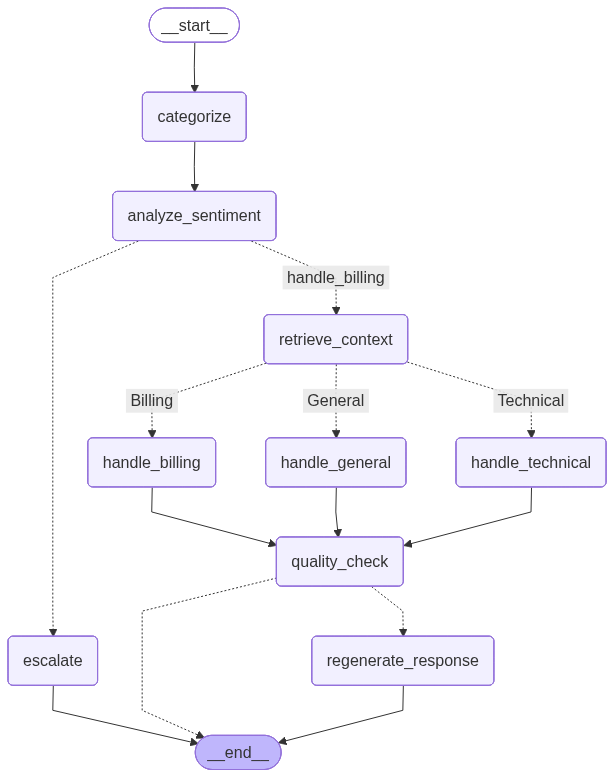

In [13]:
workflow = StateGraph(State)

# Add nodes
workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("retrieve_context", retrieve_context)    # ← new
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)
workflow.add_node("quality_check", quality_check)
workflow.add_node("regenerate_response", regenerate_response)

# Add edges
workflow.add_edge(START, "categorize")
workflow.add_edge("categorize", "analyze_sentiment")
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "handle_technical": "retrieve_context",    # ← goes to retrieval first
        "handle_billing": "retrieve_context",      # ← goes to retrieval first
        "handle_general": "retrieve_context",      # ← goes to retrieval first
        "escalate": "escalate"                     # ← escalate skips retrieval
    }
)

# After retrieval route to correct handler based on category
workflow.add_conditional_edges(
    "retrieve_context",
    lambda state: state["category"],               # ← route by category
    {
        "Technical": "handle_technical",
        "Billing": "handle_billing",
        "General": "handle_general",
    }
)

workflow.add_edge("handle_technical", "quality_check")
workflow.add_edge("handle_billing", "quality_check")
workflow.add_edge("handle_general", "quality_check")
workflow.add_edge("escalate", END)

workflow.add_conditional_edges(
    "quality_check",
    route_quality,
    {
        "regenerate_response": "regenerate_response",
        END: END
    }
)
workflow.add_edge("regenerate_response", END)

app = workflow.compile()
app

In [14]:
# Should use knowledge base context for password reset
result = app.invoke({"query": "How do I reset my password?"})
print(f"Category: {result['category']}, Confidence: {result['confidence']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Quality: {result['quality_score']}")
print(f"\nContext retrieved:\n{result['context']}")
print(f"\nResponse:\n{result['response']}")

Category: Technical, Confidence: 0.95
Sentiment: Neutral
Quality: 1.0

Context retrieved:
will receive a password reset email within 2 minutes. Click the link in the email, which expires after 30
minutes, and enter your new password. Your new password must be at least 8 characters and include one
uppercase letter and one number.
Q: My account is locked. What should I do?
Accounts are automatically locked after 5 consecutive failed login attempts as a security measure. Wait 15
minutes for the lock to expire and try again. If you continue to experience issues, contact support at

NovaTech Solutions
Technical Support FAQ
This document covers common technical issues and their solutions for NovaTech Solutions products.
Account and Login Issues
Q: How do I reset my password?
To reset your password, visit the NovaTech login page at app.novatech.io and click the 'Forgot Password?'
link below the sign-in form. Enter the email address associated with your account and click Submit. You

support@n